In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_state_city


# Squaring Circuit: $U|x\rangle|0\rangle = |x\rangle|x^2 \bmod 2^n\rangle$

## Why two registers?

The map $x \mapsto x^2 \bmod 2^n$ is **not injective** — for example, $1^2 \equiv 7^2 \equiv 1 \pmod{8}$. So it cannot be implemented as a unitary on a single register. We need:
- **Input register** $|x\rangle$: $n$ qubits, preserved
- **Output register** $|y\rangle$: $n$ qubits, initialized to $|0\rangle$, receives $x^2 \bmod 2^n$

## Algorithm: Shift-and-Add Squaring

To compute $x^2 = x \cdot x$, we multiply $x$ by itself using the schoolbook method:

$$x^2 = x \cdot \left(\sum_{k=0}^{n-1} x_k \cdot 2^k\right) = \sum_{k=0}^{n-1} x_k \cdot (x \cdot 2^k)$$

For each bit $x_k = 1$, we add $x \cdot 2^k$ (i.e., $x$ shifted left by $k$) to the accumulator, all mod $2^n$.

Each addition uses a **controlled ripple-carry adder**: controlled on bit $x_k$, adding the (shifted) input register into the output register.

In [3]:
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate


def squaring_circuit(n):
    """Build a circuit that computes |x⟩|y⟩ → |x⟩|y ⊕ (x² mod 2^n)⟩.

    When y=0: |x⟩|0⟩ → |x⟩|x² mod 2^n⟩.

    The XOR-based definition makes it its own inverse (involutory),
    since applying twice: y ⊕ x² ⊕ x² = y.

    Layout (little-endian):
        qubits 0..n-1   = input register x (LSB first)
        qubits n..2n-1  = output register y (LSB first)

    Implementation: direct unitary from truth table (practical for n ≤ 5).
    """
    N = 2 ** n
    dim = N * N

    perm = np.zeros((dim, dim))
    for x in range(N):
        x_sq = (x * x) % N
        for y in range(N):
            y_out = y ^ x_sq
            idx_in  = y * N + x
            idx_out = y_out * N + x
            perm[idx_out, idx_in] = 1.0

    qc = QuantumCircuit(2 * n)
    gate = UnitaryGate(perm, label=f'x²mod{N}')
    qc.append(gate, range(2 * n))
    return qc


# Build for small n
for n_test in [2, 3, 4]:
    qc_sq = squaring_circuit(n_test)
    qc_sq_t = transpile(qc_sq, basis_gates=['u', 'cx'], optimization_level=2)
    print(f"n={n_test}:  {qc_sq_t.num_qubits} qubits,  "
          f"{qc_sq_t.count_ops().get('cx', 0)} CX gates")


n=2:  4 qubits,  94 CX gates
n=3:  6 qubits,  1840 CX gates
n=4:  8 qubits,  30896 CX gates


In [4]:
# --- Verify squaring circuit for all basis states ---
n = 3
N = 2 ** n
qc_sq = squaring_circuit(n)

print(f"Verification: n={n}, mapping x → x² mod {N}\n")
print(f"  {'|x⟩':>5s}  {'x':>3s}  {'x²mod{}'.format(N):>8s}  {'measured y':>10s}  {'correct?':>8s}")
print("  " + "─" * 42)

all_correct = True
for x in range(N):
    # Prepare |x⟩|0⟩
    qc_test = QuantumCircuit(2 * n)
    # Set input register bits (little-endian)
    for bit in range(n):
        if (x >> bit) & 1:
            qc_test.x(bit)

    # Apply squaring circuit
    qc_test.compose(qc_sq, inplace=True)

    # Get statevector
    sv = Statevector.from_instruction(qc_test)
    probs = sv.probabilities_dict()

    # Find the output: the single basis state with probability 1
    result_state = max(probs, key=probs.get)

    # Parse result: Qiskit returns bits in reversed order (MSB first in string)
    # result_state is a 2n-bit string, MSB of y first
    y_bits = result_state[:n]   # high n bits = y register (MSB first)
    x_bits = result_state[n:]   # low n bits = x register (MSB first)
    y_meas = int(y_bits, 2)
    x_meas = int(x_bits, 2)

    expected = (x * x) % N
    ok = (y_meas == expected) and (x_meas == x)
    if not ok:
        all_correct = False

    print(f"  |{x:0{n}b}⟩  {x:>3d}  {expected:>8d}  {y_meas:>10d}  {'✓' if ok else '✗':>8s}")

print(f"\n{'All correct!' if all_correct else 'ERRORS FOUND'}")


Verification: n=3, mapping x → x² mod 8

    |x⟩    x    x²mod8  measured y  correct?
  ──────────────────────────────────────────
  |000⟩    0         0           0         ✓
  |001⟩    1         1           1         ✓
  |010⟩    2         4           4         ✓
  |011⟩    3         1           1         ✓
  |100⟩    4         0           0         ✓
  |101⟩    5         1           1         ✓
  |110⟩    6         4           4         ✓
  |111⟩    7         1           1         ✓

All correct!


Measurement of output register (y = x² mod 8)
Input: uniform superposition over x = 0..7

    y  expected prob  measured prob   shots
  ──────────────────────────────────────────
    0         0.2500         0.2494    2494
    1         0.5000         0.4998    4998
    4         0.2500         0.2508    2508


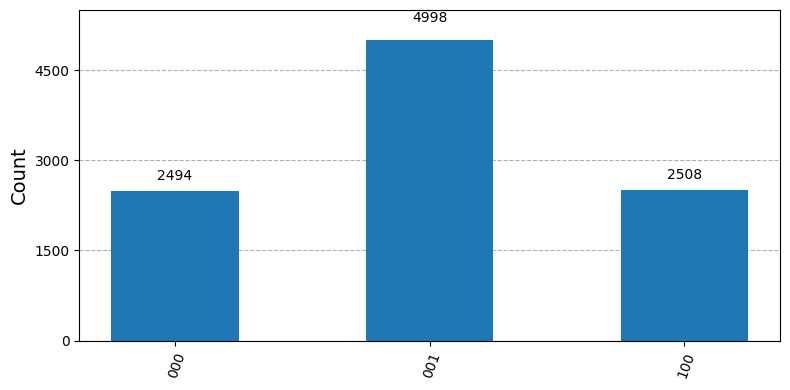

In [5]:
# --- Apply to uniform superposition: (1/√N) Σ_x |x⟩|0⟩ → (1/√N) Σ_x |x⟩|x²mod N⟩ ---
n = 3
N = 2 ** n

qc_super = QuantumCircuit(2 * n, n)  # measure only output register
# Hadamard on input register to create uniform superposition
for i in range(n):
    qc_super.h(i)
qc_super.barrier()
# Apply squaring
qc_super.compose(squaring_circuit(n), inplace=True)
qc_super.barrier()
# Measure output register (qubits n..2n-1)
qc_super.measure(list(range(n, 2 * n)), list(range(n)))

# Simulate
from qiskit_aer import AerSimulator
sim = AerSimulator()
shots = 10000
result = sim.run(qc_super, shots=shots).result()
counts = result.get_counts()

# Expected: each x² mod N value appears with probability proportional to
# how many x values map to it
print(f"Measurement of output register (y = x² mod {N})")
print(f"Input: uniform superposition over x = 0..{N-1}\n")

# Count expected multiplicities
from collections import Counter
expected_counts = Counter()
for x in range(N):
    expected_counts[(x*x) % N] += 1

print(f"  {'y':>3s}  {'expected prob':>13s}  {'measured prob':>13s}  {'shots':>6s}")
print("  " + "─" * 42)
for y_val in sorted(expected_counts.keys()):
    y_key = format(y_val, f'0{n}b')
    exp_prob = expected_counts[y_val] / N
    meas_count = counts.get(y_key, 0)
    meas_prob = meas_count / shots
    print(f"  {y_val:>3d}  {exp_prob:>13.4f}  {meas_prob:>13.4f}  {meas_count:>6d}")

plot_histogram(counts, figsize=(8, 4), bar_labels=True)


In [8]:
for n in range(1,9):
    print(f"n={n}")
    for x in range(2**n):
        print(f"{x}² mod {2**n} = {x*x % (2**n)}")

n=1
0² mod 2 = 0
1² mod 2 = 1
n=2
0² mod 4 = 0
1² mod 4 = 1
2² mod 4 = 0
3² mod 4 = 1
n=3
0² mod 8 = 0
1² mod 8 = 1
2² mod 8 = 4
3² mod 8 = 1
4² mod 8 = 0
5² mod 8 = 1
6² mod 8 = 4
7² mod 8 = 1
n=4
0² mod 16 = 0
1² mod 16 = 1
2² mod 16 = 4
3² mod 16 = 9
4² mod 16 = 0
5² mod 16 = 9
6² mod 16 = 4
7² mod 16 = 1
8² mod 16 = 0
9² mod 16 = 1
10² mod 16 = 4
11² mod 16 = 9
12² mod 16 = 0
13² mod 16 = 9
14² mod 16 = 4
15² mod 16 = 1
n=5
0² mod 32 = 0
1² mod 32 = 1
2² mod 32 = 4
3² mod 32 = 9
4² mod 32 = 16
5² mod 32 = 25
6² mod 32 = 4
7² mod 32 = 17
8² mod 32 = 0
9² mod 32 = 17
10² mod 32 = 4
11² mod 32 = 25
12² mod 32 = 16
13² mod 32 = 9
14² mod 32 = 4
15² mod 32 = 1
16² mod 32 = 0
17² mod 32 = 1
18² mod 32 = 4
19² mod 32 = 9
20² mod 32 = 16
21² mod 32 = 25
22² mod 32 = 4
23² mod 32 = 17
24² mod 32 = 0
25² mod 32 = 17
26² mod 32 = 4
27² mod 32 = 25
28² mod 32 = 16
29² mod 32 = 9
30² mod 32 = 4
31² mod 32 = 1
n=6
0² mod 64 = 0
1² mod 64 = 1
2² mod 64 = 4
3² mod 64 = 9
4² mod 64 = 16
5² mod 64 =

## Can phases make squaring injective on a single register?

**Idea:** Since $x^2 \bmod 2^n$ has collisions (multiple $x$ values map to the same output), assign different phases to distinguish them:

$$U|x\rangle = e^{i\phi(x)} |x^2 \bmod 2^n\rangle$$

**Problem:** This violates unitarity. If $x_1 \neq x_2$ but $x_1^2 \equiv x_2^2 \pmod{2^n}$, then:

$$\langle x_1|x_2\rangle = 0 \quad\text{(orthogonal inputs)}$$

but

$$\langle Ux_1|Ux_2\rangle = e^{i(\phi_2-\phi_1)}\underbrace{\langle y|y\rangle}_{=1} \neq 0 \quad\text{(non-orthogonal outputs)}$$

Unitarity requires $\langle Ux_1|Ux_2\rangle = \langle x_1|x_2\rangle$, so this is impossible — no choice of phases can fix it. Two states pointing in the same direction $|y\rangle$ are **never orthogonal**, regardless of their relative phase.

In [9]:
# Numerical demonstration: try to build U with U|x⟩ = e^{iφ(x)} |x² mod 2^n⟩
# and verify it cannot be unitary

n = 3
N = 2**n

# Build the collision structure
from collections import defaultdict
collisions = defaultdict(list)
for x in range(N):
    y = (x*x) % N
    collisions[y].append(x)

print(f"n={n}, N={N}")
print("Collision structure  y ← [x values]:")
for y in sorted(collisions):
    print(f"  {y} ← {collisions[y]}")

# Attempt 1: assign phases e^{2πi k/m} to the m pre-images of each y
U = np.zeros((N, N), dtype=complex)
for y, xs in collisions.items():
    m = len(xs)
    for k, x in enumerate(xs):
        phase = np.exp(2j * np.pi * k / m)
        U[y, x] = phase

print(f"\nU†U (should be identity for unitary):")
UtU = U.conj().T @ U
print(np.round(UtU, 3))
print(f"\n‖U†U - I‖ = {np.linalg.norm(UtU - np.eye(N)):.4f}")
print("→ NOT unitary!" if np.linalg.norm(UtU - np.eye(N)) > 0.01 else "→ Unitary!")

n=3, N=8
Collision structure  y ← [x values]:
  0 ← [0, 4]
  1 ← [1, 3, 5, 7]
  4 ← [2, 6]

U†U (should be identity for unitary):
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+1.j  0.+0.j -1.+0.j  0.+0.j -0.-1.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.-1.j  0.+0.j  1.+0.j  0.+0.j  0.+1.j  0.+0.j -1.+0.j]
 [-1.-0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.-0.j  0.+0.j  0.-1.j  0.+0.j  1.+0.j  0.+0.j  0.+1.j]
 [ 0.+0.j  0.+0.j -1.-0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j -0.+1.j  0.+0.j -1.-0.j  0.+0.j  0.-1.j  0.+0.j  1.+0.j]]

‖U†U - I‖ = 4.0000
→ NOT unitary!
